<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/Catalina_Nunez_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Fuga de Clientes (Churn)
### BIY7121 Minería de Datos — DuocUC
**Alumna:** Catalina Soledad Núñez Yáñez

---

## 1. Business Understanding — ¿Qué problema estamos resolviendo?

Una empresa de telecomunicaciones en California tiene un problema clásico: los clientes se van y eso cuesta plata. No solo se pierde el ingreso mensual del cliente que se fue, sino que además conseguir uno nuevo sale mucho más caro que haberlo retenido.

El objetivo de este proyecto es usar los datos históricos de 7.043 clientes para **predecir quiénes tienen más probabilidad de irse**, antes de que lo hagan. Así, el equipo de marketing puede actuar a tiempo con ofertas personalizadas.

Las variables que intuitivamente deberían importar más son:
- **Contract**: un cliente mes a mes puede irse cuando quiera, uno con contrato anual no
- **tenure**: mientras más tiempo lleva el cliente, menos probable que se vaya
- **MonthlyCharges**: si paga mucho y no ve valor, probablemente se vaya
- **InternetService**: los de fibra óptica suelen tener más opciones de irse a la competencia

## 2. Carga e Ingesta de Datos

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

df = pd.read_csv('churn.csv')
print(f'El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas')
df.head()

El dataset tiene 7043 filas y 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Revisamos los tipos de datos de cada columna
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [6]:
# TotalCharges viene como texto (object) en vez de número — hay que convertirla
# Esto pasa porque algunas filas tienen espacios en blanco en esa columna
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Tipo de TotalCharges después de la conversión:', df['TotalCharges'].dtype)

Tipo de TotalCharges después de la conversión: float64


## 3. Data Understanding — Explorando los datos (EDA)

In [7]:
# Primero vemos cuántos valores nulos hay en cada columna
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [8]:
# Los nulos en TotalCharges son clientes nuevos (tenure=0) que todavía no tienen cobros
# Los eliminamos porque son solo 11 filas sobre 7043 — no afecta nada
df.dropna(inplace=True)
print(f'Dataset después de limpiar nulos: {df.shape[0]} filas')

Dataset después de limpiar nulos: 7032 filas


Distribución de Churn:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Porcentaje de fuga: 26.6%


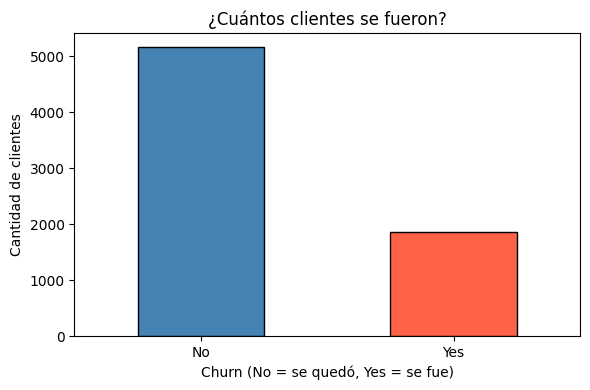

In [9]:
# ¿Cuántos clientes se fueron vs cuántos se quedaron?
print('Distribución de Churn:')
print(df['Churn'].value_counts())
print(f'\nPorcentaje de fuga: {df["Churn"].value_counts(normalize=True)["Yes"]*100:.1f}%')

plt.figure(figsize=(6,4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='black')
plt.title('¿Cuántos clientes se fueron?')
plt.xlabel('Churn (No = se quedó, Yes = se fue)')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

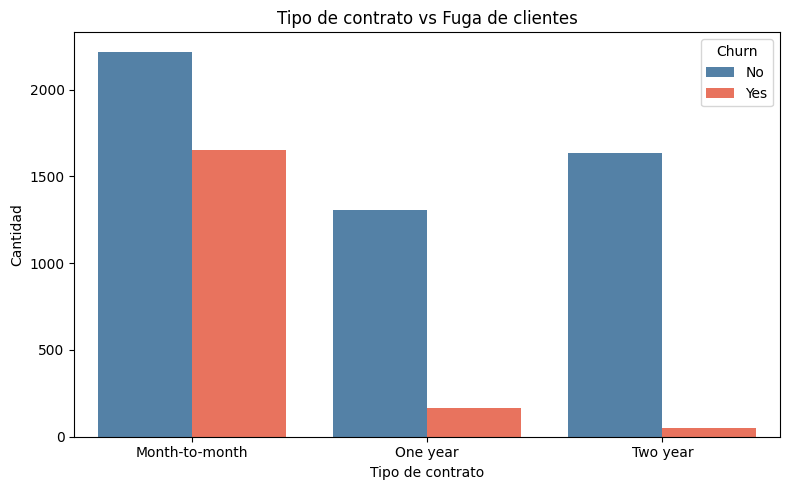

In [10]:
# ¿El tipo de contrato influye en que el cliente se vaya?
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Contract', hue='Churn', palette=['steelblue','tomato'])
plt.title('Tipo de contrato vs Fuga de clientes')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

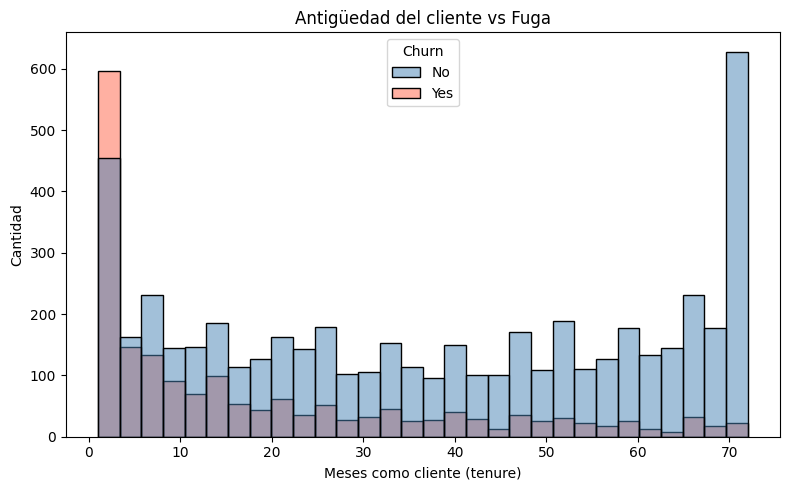

In [11]:
# ¿Cuánto tiempo llevan los clientes que se fueron vs los que se quedaron?
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['steelblue','tomato'])
plt.title('Antigüedad del cliente vs Fuga')
plt.xlabel('Meses como cliente (tenure)')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

In [12]:
# Estadísticas generales de las variables numéricas
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


### 3.1 Detección de Outliers con Boxplots y método IQR

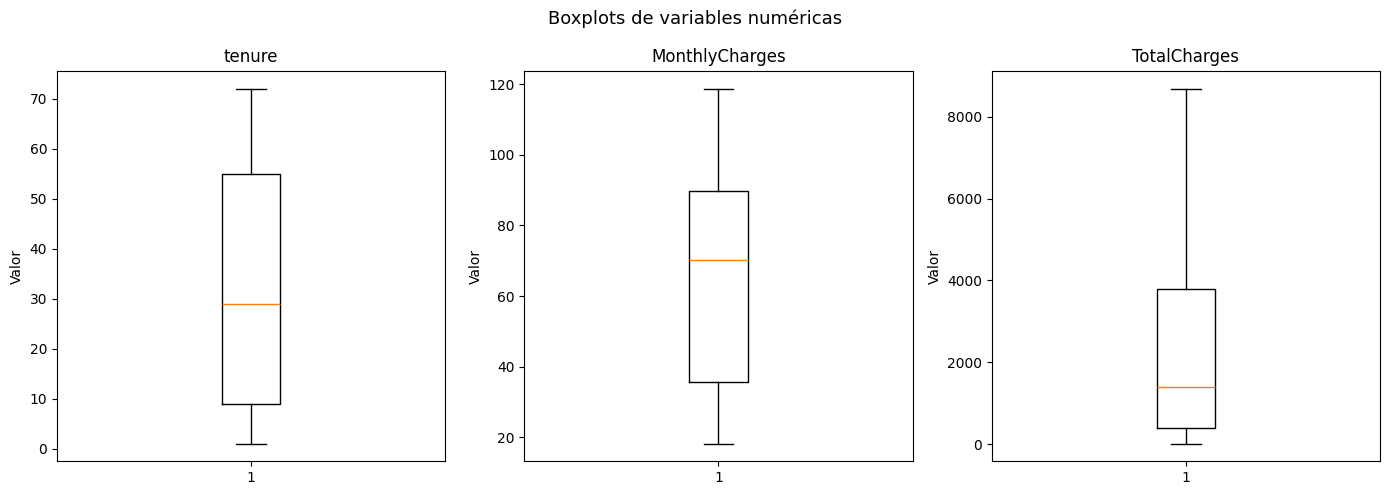

In [13]:
# Visualizamos los boxplots de las variables numéricas para ver si hay valores raros
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots de variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# Calculamos los outliers con el método IQR (el rango entre el 25% y 75% de los datos)
# Si un valor está muy por encima o por debajo de ese rango, es un outlier

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f'{col}: {len(outliers)} outliers | Rango normal: [{limite_inferior:.1f}, {limite_superior:.1f}]')

tenure: 0 outliers | Rango normal: [-60.0, 124.0]
MonthlyCharges: 0 outliers | Rango normal: [-45.8, 171.3]
TotalCharges: 0 outliers | Rango normal: [-4688.5, 8884.7]


In [15]:
# En este caso no hay outliers problemáticos — los valores extremos son simplemente
# clientes que llevan muchos años o pagan montos altos, lo cual es completamente normal
# en una empresa de telecomunicaciones. No los eliminamos.
print('No se eliminan outliers. Los valores extremos son clientes reales y válidos.')
print(f'Dataset final: {df.shape[0]} filas')

No se eliminan outliers. Los valores extremos son clientes reales y válidos.
Dataset final: 7032 filas


### 3.2 Matriz de Correlación

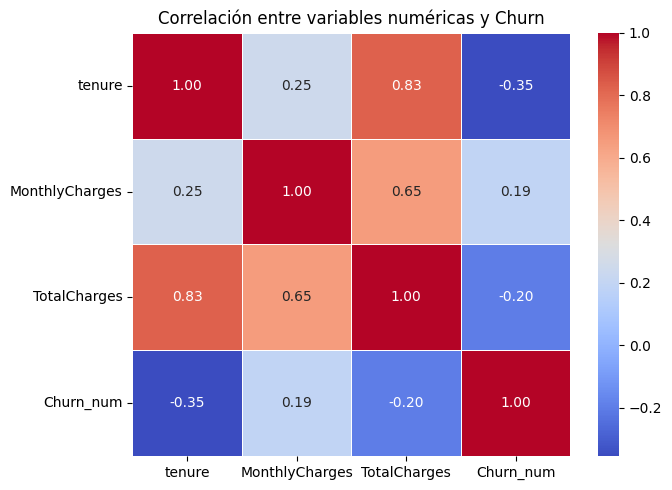

In [16]:
# La correlación nos dice qué tan relacionadas están las variables numéricas entre sí
# y con el Churn. Valores cercanos a 1 o -1 indican relación fuerte.

# Convertimos Churn a número para incluirlo en la correlación
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_matrix = df_corr[['tenure','MonthlyCharges','TotalCharges','Churn_num']].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlación entre variables numéricas y Churn')
plt.tight_layout()
plt.show()

## 4. Data Preparation — Preparando los datos para los modelos

In [17]:
# Sacamos el customerID porque es solo un identificador, no aporta nada al modelo
df_model = df.drop(columns=['customerID'])

# Separamos la columna objetivo (lo que queremos predecir) del resto
X = df_model.drop(columns=['Churn'])
y = (df_model['Churn'] == 'Yes').astype(int)  # 1 = se fue, 0 = se quedó

print('Variables para entrenar el modelo:', X.shape[1])
print('Distribución del target:')
print(y.value_counts())

Variables para entrenar el modelo: 19
Distribución del target:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [18]:
# Las variables de texto hay que convertirlas a números porque los modelos no entienden palabras
# Usamos Label Encoding para las columnas binarias (Solo tienen 2 valores posibles)
# y One-Hot Encoding para las que tienen más de 2 opciones

# Variables binarias: las codificamos directo con LabelEncoder
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    X[col] = le.fit_transform(X[col])

# Variables con más de 2 categorías: usamos dummies (One-Hot Encoding)
X = pd.get_dummies(X, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)

print('Total de columnas después de la transformación:', X.shape[1])
print(X.dtypes)

Total de columnas después de la transformación: 23
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year                           bool
Contract_Two year 

In [19]:
# Dividimos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'Datos de entrenamiento: {X_train.shape[0]} filas')
print(f'Datos de prueba: {X_test.shape[0]} filas')

Datos de entrenamiento: 4922 filas
Datos de prueba: 2110 filas


In [20]:
# StandardScaler normaliza los números para que todos estén en la misma escala
# Esto es especialmente importante para SVM y Regresión Logística
# (si una variable va de 0-100 y otra de 0-1, el modelo puede confundirse)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Escalado aplicado correctamente')

Escalado aplicado correctamente


### 4.1 Manejo del Desbalance de Clases con SMOTE

El dataset tiene un problema: solo el ~26% de los clientes hizo churn. Eso significa que si el modelo simplemente predice "nadie se va", igual tendría 74% de accuracy — pero sería inútil para el negocio.

Para solucionar esto usamos **SMOTE** (Synthetic Minority Oversampling Technique), que crea ejemplos sintéticos de la clase minoritaria (los que se van) para balancear el dataset.

In [21]:
print('Distribución ANTES de SMOTE:')
print(pd.Series(y_train).value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\nDistribución DESPUÉS de SMOTE:')
print(pd.Series(y_train_sm).value_counts())

Distribución ANTES de SMOTE:
Churn
0    3614
1    1308
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
Churn
1    3614
0    3614
Name: count, dtype: int64


## 5. Modeling & Evaluation — Entrenando y comparando los modelos

In [22]:
# Función para evaluar cada modelo de manera uniforme
def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f'\n{'='*50}')
    print(f'Modelo: {nombre}')
    print(f'Accuracy: {acc:.4f} ({acc*100:.1f}%)')
    print(f'F1-Score: {f1:.4f}')
    print(f'\nReporte completo:')
    print(classification_report(y_test, y_pred, target_names=['Se queda','Se va']))

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predijo: Se queda','Predijo: Se va'],
                yticklabels=['Real: Se queda','Real: Se va'])
    plt.title(f'Matriz de Confusión — {nombre}')
    plt.tight_layout()
    plt.show()

    return modelo, acc, f1, y_pred

### 5.1 Modelo 1: Regresión Logística


Modelo: Regresión Logística
Accuracy: 0.7412 (74.1%)
F1-Score: 0.6171

Reporte completo:
              precision    recall  f1-score   support

    Se queda       0.90      0.73      0.80      1549
       Se va       0.51      0.78      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.75      0.71      2110
weighted avg       0.80      0.74      0.75      2110



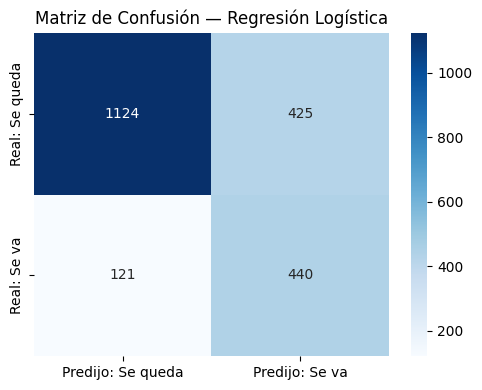

In [23]:
# La regresión logística calcula la probabilidad de que un cliente se vaya
# Es simple pero muy interpretable — ideal como punto de partida

lr = LogisticRegression(max_iter=1000, random_state=42, C=0.5)
lr_model, lr_acc, lr_f1, lr_pred = evaluar_modelo(
    'Regresión Logística', lr, X_train_sm, y_train_sm, X_test_scaled, y_test
)

### 5.2 Modelo 2: SVM (Support Vector Machine)


Modelo: SVM
Accuracy: 0.7616 (76.2%)
F1-Score: 0.6169

Reporte completo:
              precision    recall  f1-score   support

    Se queda       0.89      0.78      0.83      1549
       Se va       0.54      0.72      0.62       561

    accuracy                           0.76      2110
   macro avg       0.71      0.75      0.72      2110
weighted avg       0.79      0.76      0.77      2110



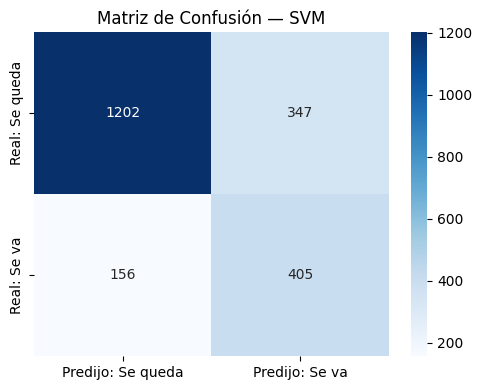

In [24]:
# SVM busca la mejor línea imaginaria que separe a los que se van de los que se quedan
# Requiere que los datos estén escalados (ya lo hicimos con StandardScaler)

svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model, svm_acc, svm_f1, svm_pred = evaluar_modelo(
    'SVM', svm, X_train_sm, y_train_sm, X_test_scaled, y_test
)

### 5.3 Modelo 3: Árbol de Decisión


Modelo: Árbol de Decisión
Accuracy: 0.7318 (73.2%)
F1-Score: 0.5863

Reporte completo:
              precision    recall  f1-score   support

    Se queda       0.88      0.74      0.80      1549
       Se va       0.50      0.71      0.59       561

    accuracy                           0.73      2110
   macro avg       0.69      0.73      0.69      2110
weighted avg       0.78      0.73      0.74      2110



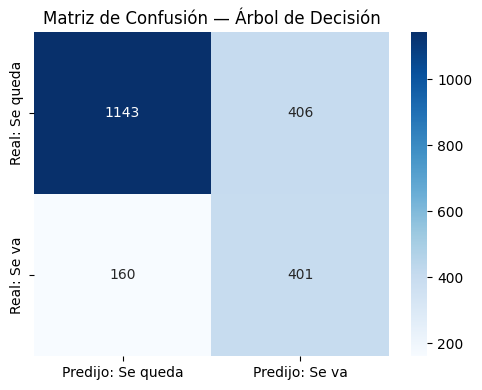

In [25]:
# El árbol de decisión hace preguntas tipo IF/ELSE para llegar a una conclusión
# Es el más fácil de explicarle a alguien que no sabe de modelos

tree = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
tree_model, tree_acc, tree_f1, tree_pred = evaluar_modelo(
    'Árbol de Decisión', tree, X_train_sm, y_train_sm, X_test_scaled, y_test
)

### 5.4 Comparación final de modelos

             Modelo  Accuracy  F1-Score  Accuracy (%)
Regresión Logística  0.741232    0.6171         74.12
                SVM  0.761611    0.6169         76.16
  Árbol de Decisión  0.731754    0.5863         73.18


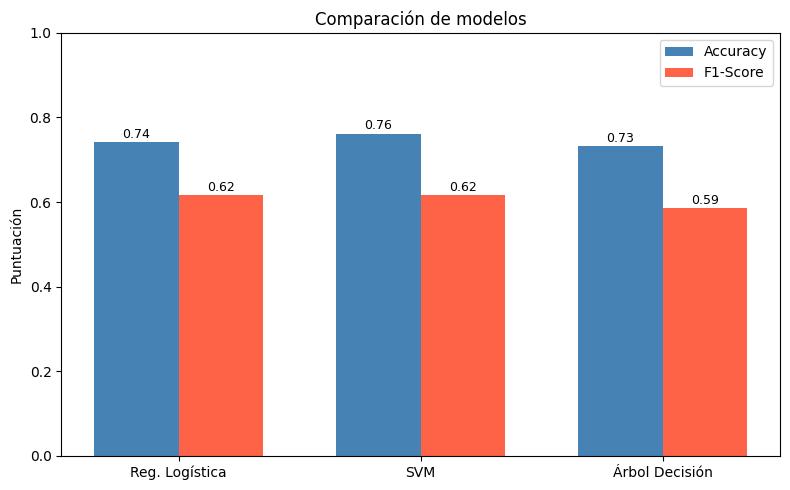

In [26]:
# Tabla resumen para comparar los 3 modelos de un vistazo
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'SVM', 'Árbol de Decisión'],
    'Accuracy': [lr_acc, svm_acc, tree_acc],
    'F1-Score': [lr_f1, svm_f1, tree_f1]
})

resultados['Accuracy (%)'] = (resultados['Accuracy'] * 100).round(2)
resultados['F1-Score'] = resultados['F1-Score'].round(4)
print(resultados.to_string(index=False))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(3)
width = 0.35
bars1 = ax.bar(x - width/2, resultados['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, resultados['F1-Score'], width, label='F1-Score', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(['Reg. Logística', 'SVM', 'Árbol Decisión'])
ax.set_ylim(0, 1)
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de modelos')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

### 5.5 Variables que más influyen en la fuga

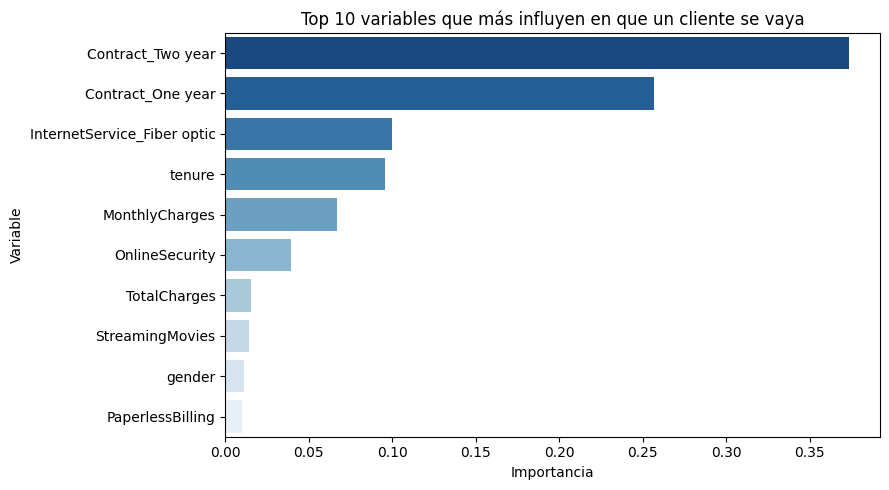

                   Variable  Importancia
          Contract_Two year     0.373470
          Contract_One year     0.256577
InternetService_Fiber optic     0.099676
                     tenure     0.095543
             MonthlyCharges     0.067024
             OnlineSecurity     0.039570
               TotalCharges     0.015558
            StreamingMovies     0.014098
                     gender     0.010922
           PaperlessBilling     0.009725


In [27]:
# El Árbol de Decisión nos dice exactamente qué variables usó más para tomar sus decisiones
# Eso se llama Feature Importance — básicamente, ¿qué le importa más al modelo?

importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': tree_model.feature_importances_
}).sort_values('Importancia', ascending=False).head(10)

plt.figure(figsize=(9,5))
sns.barplot(data=importancias, x='Importancia', y='Variable', palette='Blues_r')
plt.title('Top 10 variables que más influyen en que un cliente se vaya')
plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))

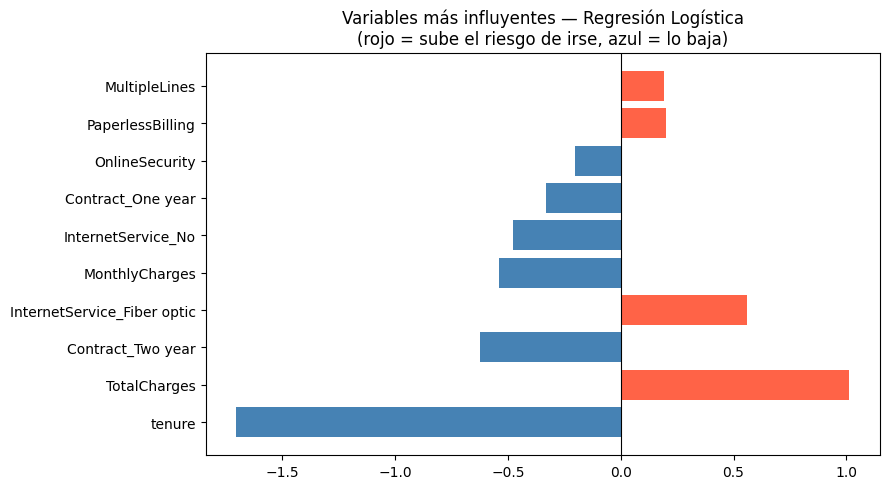

In [28]:
# Para la Regresión Logística también podemos ver qué variables pesan más
# Los coeficientes positivos aumentan la probabilidad de irse, los negativos la reducen

coefs = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(10)

plt.figure(figsize=(9,5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coefs['Coeficiente']]
plt.barh(coefs['Variable'], coefs['Coeficiente'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Variables más influyentes — Regresión Logística\n(rojo = sube el riesgo de irse, azul = lo baja)')
plt.tight_layout()
plt.show()

## 6. Insights de Alto Impacto — ¿Qué nos dicen los datos?

Después de analizar los resultados, estos son los patrones más importantes que encontramos:

**1. El contrato mes a mes es el mayor predictor de fuga**
Los clientes sin contrato de largo plazo se pueden ir cuando quieran y efectivamente lo hacen con mucha más frecuencia. Un cliente con contrato mensual tiene un riesgo de fuga varias veces mayor que uno con contrato de 2 años.

**2. Los clientes nuevos son los más vulnerables**
La variable tenure muestra que la mayoría de los que se van tienen menos de 12 meses. Si un cliente supera el primer año, es mucho más probable que se quede.

**3. Fibra óptica + contrato mensual = perfil de alto riesgo**
Los clientes con fibra óptica pagan más y tienen más alternativas en el mercado. Si además tienen contrato mes a mes, son el segmento con mayor probabilidad de irse.

**4. Las cargas mensuales altas sin servicios adicionales generan fuga**
Clientes que pagan mucho pero no usan servicios como seguridad online o soporte técnico no perciben valor y se van más fácilmente.

## 7. Métricas de Costo-Beneficio — ¿Cuánto dinero ahorran los modelos?

In [29]:
# Regla del negocio:
# - Retener a un cliente que iba a irse cuesta $10 (oferta de retención)
# - Perder a un cliente cuesta $100 (ingreso perdido)
# - Retener a un cliente que igual se iba a quedar: gastamos $10 innecesariamente

costo_retencion = 10
costo_perdida = 100

def calcular_ahorro(y_real, y_predicho, nombre_modelo):
    cm = confusion_matrix(y_real, y_predicho)
    TN, FP, FN, TP = cm.ravel()

    # TP: predijo que se iba y tenía razón → gastamos $10 en retenerlo, ahorramos $100
    ahorro_tp = TP * (costo_perdida - costo_retencion)
    # FP: predijo que se iba pero no era así → gastamos $10 innecesariamente
    costo_fp = FP * costo_retencion
    # FN: no detectó que se iba → perdemos $100 por cada uno
    costo_fn = FN * costo_perdida

    ahorro_neto = ahorro_tp - costo_fp - costo_fn

    print(f'\n--- {nombre_modelo} ---')
    print(f'Clientes en riesgo detectados correctamente (TP): {TP}')
    print(f'Falsas alarmas (FP, oferta innecesaria): {FP}')
    print(f'Clientes perdidos sin detectar (FN): {FN}')
    print(f'Ahorro por retenciones exitosas: ${ahorro_tp:,.0f}')
    print(f'Costo por falsas alarmas: ${costo_fp:,.0f}')
    print(f'Costo por no detectar churn: ${costo_fn:,.0f}')
    print(f'AHORRO NETO: ${ahorro_neto:,.0f}')
    return ahorro_neto

ahorro_lr  = calcular_ahorro(y_test, lr_pred,   'Regresión Logística')
ahorro_svm = calcular_ahorro(y_test, svm_pred,  'SVM')
ahorro_dt  = calcular_ahorro(y_test, tree_pred, 'Árbol de Decisión')


--- Regresión Logística ---
Clientes en riesgo detectados correctamente (TP): 440
Falsas alarmas (FP, oferta innecesaria): 425
Clientes perdidos sin detectar (FN): 121
Ahorro por retenciones exitosas: $39,600
Costo por falsas alarmas: $4,250
Costo por no detectar churn: $12,100
AHORRO NETO: $23,250

--- SVM ---
Clientes en riesgo detectados correctamente (TP): 405
Falsas alarmas (FP, oferta innecesaria): 347
Clientes perdidos sin detectar (FN): 156
Ahorro por retenciones exitosas: $36,450
Costo por falsas alarmas: $3,470
Costo por no detectar churn: $15,600
AHORRO NETO: $17,380

--- Árbol de Decisión ---
Clientes en riesgo detectados correctamente (TP): 401
Falsas alarmas (FP, oferta innecesaria): 406
Clientes perdidos sin detectar (FN): 160
Ahorro por retenciones exitosas: $36,090
Costo por falsas alarmas: $4,060
Costo por no detectar churn: $16,000
AHORRO NETO: $16,030


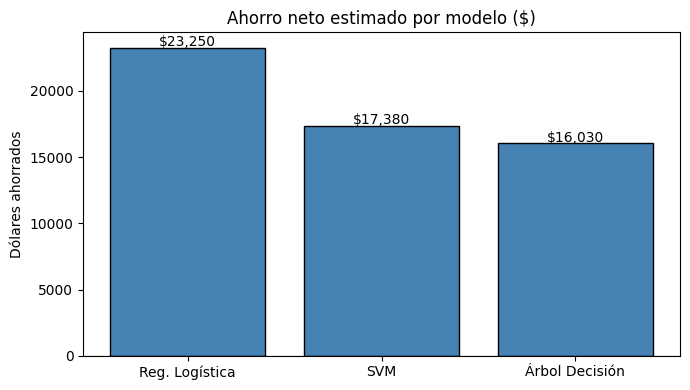

In [30]:
# Comparamos los ahorros de los 3 modelos
modelos = ['Reg. Logística', 'SVM', 'Árbol Decisión']
ahorros = [ahorro_lr, ahorro_svm, ahorro_dt]

plt.figure(figsize=(7,4))
colores = ['steelblue' if a >= 0 else 'tomato' for a in ahorros]
plt.bar(modelos, ahorros, color=colores, edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Ahorro neto estimado por modelo ($)')
plt.ylabel('Dólares ahorrados')
for i, v in enumerate(ahorros):
    plt.text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Propuestas Prácticas — ¿Qué debería hacer la empresa?

Basándose directamente en los hallazgos del modelo, estas son 3 acciones concretas que la empresa puede tomar:

**1. Campaña de migración de contratos en el primer trimestre**
Los clientes nuevos (menos de 3 meses) con contrato mes a mes deben recibir una oferta personalizada para migrar a un contrato anual. El modelo indica que este grupo es el de mayor riesgo. Un descuento del 15% en el primer año es mucho más barato que perder al cliente.

**2. Programa de fidelización para usuarios de fibra óptica**
Los clientes de fibra óptica que no tienen ningún servicio adicional contratado (sin seguridad online, sin soporte técnico) tienen un perfil de riesgo alto. Ofrecerles uno de estos servicios gratis por 3 meses puede aumentar su percepción de valor y reducir la fuga.

**3. Alertas automáticas para el equipo de retención**
Implementar el modelo en producción para que cada mes genere una lista de clientes con probabilidad de churn > 70%. El equipo de retención contactaría proactivamente solo a esos clientes, optimizando los recursos y maximizando el ahorro calculado en el punto anterior.